In [ ]:
# SETUP

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

from pathlib import Path
import json
import zipfile
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import torch
import torch.nn as nn

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

# PROJECT PATHS

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/intentmap-nids/intentmap-nids"
)

DATA_DIR = PROJECT_ROOT / "data"
UNSW_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"
CONFIG_DIR = PROJECT_ROOT / "config"

# Save NEW testing results separately
RESULT_DIR = (
    PROJECT_ROOT /
    "results" /
    "gns3_zeek_v5_recalibrated"
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# NEW PRACTICAL DATASET

X_FILE = (
    DATA_DIR /
    "combined_practical_traffic_v5_41_features.csv"
)

METADATA_FILE = (
    DATA_DIR /
    "combined_practical_traffic_v5_metadata.csv"
)

# Same UNSW normal validation data used for thresholds
VAL_FILE = (
    UNSW_DIR /
    "val_normal.npz"
)

# CHECK FILES

print("41-feature data:", X_FILE.exists())
print("Metadata:", METADATA_FILE.exists())
print("UNSW validation:", VAL_FILE.exists())
print("Result folder:", RESULT_DIR)

Mounted at /content/drive
41-feature data: True
Metadata: True
UNSW validation: True
Result folder: /content/drive/MyDrive/intentmap-nids/intentmap-nids/results/gns3_zeek_v5_recalibrated


In [ ]:
# LOAD GNS3/ZEEK DATA + CREATE NORMAL-ONLY CALIBRATION SPLIT

X_zeek_df = pd.read_csv(X_FILE)
metadata = pd.read_csv(METADATA_FILE)

X_zeek = X_zeek_df.to_numpy(
    dtype=np.float32
)

y_zeek = metadata[
    "label"
].to_numpy(
    dtype=np.int8
)

with np.load(VAL_FILE) as data:
    X_val = data["X"].astype(
        np.float32
    )

print("Full Zeek features:", X_zeek.shape)
print("Metadata:", metadata.shape)

print("\nFULL PRACTICAL DATASET")
print(
    "Normal:",
    int((y_zeek == 0).sum())
)
print(
    "Attack:",
    int((y_zeek == 1).sum())
)

print("\nData sources:")
print(
    metadata["data_source"].value_counts()
)

# CALIBRATION DATA
# internal_gns3_v4 = separate normal-only practical traffic

calibration_mask = (
    metadata["data_source"]
    == "internal_gns3_v4"
).to_numpy()

calibration_idx = np.flatnonzero(
    calibration_mask
)

# Everything except v4 becomes final test data
test_idx = np.flatnonzero(
    ~calibration_mask
)

# Ground truth for final held-out test
y_test = y_zeek[test_idx]

# Metadata aligned with held-out test
metadata_test = (
    metadata
    .iloc[test_idx]
    .reset_index(drop=True)
)

# CHECK CALIBRATION SET

print("\nCALIBRATION SET")
print(
    "Records:",
    len(calibration_idx)
)

print(
    "Normal:",
    int(
        (y_zeek[calibration_idx] == 0).sum()
    )
)

print(
    "Attack:",
    int(
        (y_zeek[calibration_idx] == 1).sum()
    )
)

# CHECK FINAL TEST SET

print("\nFINAL HELD-OUT TEST SET")
print(
    "Records:",
    len(test_idx)
)

print(
    "Normal:",
    int((y_test == 0).sum())
)

print(
    "Attack:",
    int((y_test == 1).sum())
)

# DATA QUALITY CHECK

print(
    "\nNaN:",
    int(np.isnan(X_zeek).sum())
)

print(
    "Infinite:",
    int(np.isinf(X_zeek).sum())
)

assert X_zeek.shape[1] == 41
assert len(X_zeek) == len(metadata)
assert len(X_zeek) == len(y_zeek)

assert np.isfinite(
    X_zeek
).all()

# Current v5 dataset checks
assert len(X_zeek) == 6966

assert len(
    calibration_idx
) == 1945

# Calibration must contain NORMAL ONLY
assert np.all(
    y_zeek[calibration_idx] == 0
)

assert len(test_idx) == 5021

assert int(
    (y_test == 0).sum()
) == 808

assert int(
    (y_test == 1).sum()
) == 4213

# No overlap
assert len(
    np.intersect1d(
        calibration_idx,
        test_idx
    )
) == 0

print("\nCALIBRATION / TEST SPLIT READY")

Full Zeek features: (6966, 41)
Metadata: (6966, 9)

FULL PRACTICAL DATASET
Normal: 2753
Attack: 4213

Data sources:
data_source
internal_gns3_v3    1974
internal_gns3_v4    1945
external_laptop     1631
internal_gns3       1416
Name: count, dtype: int64

CALIBRATION SET
Records: 1945
Normal: 1945
Attack: 0

FINAL HELD-OUT TEST SET
Records: 5021
Normal: 808
Attack: 4213

NaN: 0
Infinite: 0

CALIBRATION / TEST SPLIT READY


In [ ]:
# Model and configuration paths

IF_MODEL_FILE = MODEL_DIR / "isolation_forest_candidate1.joblib"
AE_MODEL_FILE = MODEL_DIR / "autoencoder_candidate1.keras"
LOF_MODEL_FILE = MODEL_DIR / "lof_baseline.joblib"
OCSVM_MODEL_FILE = MODEL_DIR / "ocsvm_model.joblib"
DEEP_MODEL_FILE = MODEL_DIR / "deep_svdd_model.pt"

IF_CONFIG_FILE = CONFIG_DIR / "isolation_forest_candidate1.json"
AE_CONFIG_FILE = CONFIG_DIR / "autoencoder_candidate1.json"
LOF_CONFIG_FILE = CONFIG_DIR / "lof_baseline.json"
OCSVM_CONFIG_FILE = CONFIG_DIR / "ocsvm_model.json"
DEEP_CONFIG_FILE = CONFIG_DIR / "deep_svdd_model.json"
HYBRID_CONFIG_FILE = CONFIG_DIR / "hybrid_if_ae.json"

required_files = [
    IF_MODEL_FILE,
    AE_MODEL_FILE,
    LOF_MODEL_FILE,
    OCSVM_MODEL_FILE,
    DEEP_MODEL_FILE,
    IF_CONFIG_FILE,
    AE_CONFIG_FILE,
    LOF_CONFIG_FILE,
    OCSVM_CONFIG_FILE,
    DEEP_CONFIG_FILE,
    HYBRID_CONFIG_FILE
]

for file in required_files:
    print(file.name, "->", file.exists())

if not all(file.exists() for file in required_files):
    raise FileNotFoundError(
        "One or more trained model/configuration files are missing."
    )

isolation_forest_candidate1.joblib -> True
autoencoder_candidate1.keras -> True
lof_baseline.joblib -> True
ocsvm_model.joblib -> True
deep_svdd_model.pt -> True
isolation_forest_candidate1.json -> True
autoencoder_candidate1.json -> True
lof_baseline.json -> True
ocsvm_model.json -> True
deep_svdd_model.json -> True
hybrid_if_ae.json -> True


In [ ]:
# Load model configurations and thresholds

def load_json(path):
    with open(path, "r") as file:
        return json.load(file)

if_config = load_json(IF_CONFIG_FILE)
ae_config = load_json(AE_CONFIG_FILE)
lof_config = load_json(LOF_CONFIG_FILE)
ocsvm_config = load_json(OCSVM_CONFIG_FILE)
deep_config = load_json(DEEP_CONFIG_FILE)
hybrid_config = load_json(HYBRID_CONFIG_FILE)

BUDGETS = [
    "0.5% budget",
    "1% budget",
    "3% budget"
]

def get_thresholds(config):
    return {
        name: float(value)
        for name, value in config["thresholds"].items()
    }

if_thresholds = get_thresholds(if_config)
ae_thresholds = get_thresholds(ae_config)
lof_thresholds = get_thresholds(lof_config)
ocsvm_thresholds = get_thresholds(ocsvm_config)
deep_thresholds = get_thresholds(deep_config)
hybrid_thresholds = get_thresholds(hybrid_config)

print("IF:", if_thresholds)
print("AE:", ae_thresholds)
print("LOF:", lof_thresholds)
print("OCSVM:", ocsvm_thresholds)
print("Deep SVDD:", deep_thresholds)
print("Hybrid:", hybrid_thresholds)

IF: {'0.5% budget': 0.5676495685072951, '1% budget': 0.5460537691550149, '3% budget': 0.4966390963721801}
AE: {'0.5% budget': 0.04577401398215515, '1% budget': 0.036467666841251495, '3% budget': 0.02375445595651247}
LOF: {'0.5% budget': 1.9827458421041482, '1% budget': 1.8009945299909127, '3% budget': 1.476140406733413}
OCSVM: {'0.5% budget': 0.715225019931776, '1% budget': -5.3313550321087755e-05, '3% budget': -1.0914602100972197}
Deep SVDD: {'0.5% budget': 8.080383850028738e-05, '1% budget': 5.488995884661563e-05, '3% budget': 3.0722618248546496e-05}
Hybrid: {'0.5% budget': 0.9909942047336122, '1% budget': 0.9800818155254699, '3% budget': 0.9389378591604168}


In [ ]:
# Load trained models

if_model = joblib.load(IF_MODEL_FILE)

ae_model = tf.keras.models.load_model(
    AE_MODEL_FILE,
    compile=False
)

lof_model = joblib.load(LOF_MODEL_FILE)
ocsvm_model = joblib.load(OCSVM_MODEL_FILE)

print("Isolation Forest loaded")
print("Autoencoder loaded")
print("LOF loaded")
print("One-Class SVM loaded")

Isolation Forest loaded
Autoencoder loaded
LOF loaded
One-Class SVM loaded


In [ ]:
# Score IF, AE, LOF and OCSVM

if_zeek_scores = -if_model.score_samples(X_zeek)
if_val_scores = -if_model.score_samples(X_val)

ae_zeek_reconstructed = ae_model.predict(
    X_zeek,
    batch_size=1024,
    verbose=0
)

ae_zeek_scores = np.mean(
    np.square(
        X_zeek - ae_zeek_reconstructed
    ),
    axis=1
)

ae_val_reconstructed = ae_model.predict(
    X_val,
    batch_size=1024,
    verbose=0
)

ae_val_scores = np.mean(
    np.square(
        X_val - ae_val_reconstructed
    ),
    axis=1
)

lof_zeek_scores = -lof_model.score_samples(
    X_zeek
)

ocsvm_zeek_scores = -ocsvm_model.decision_function(
    X_zeek
).reshape(-1)

print("IF:", if_zeek_scores.shape)
print("AE:", ae_zeek_scores.shape)
print("LOF:", lof_zeek_scores.shape)
print("OCSVM:", ocsvm_zeek_scores.shape)

IF: (6966,)
AE: (6966,)
LOF: (6966,)
OCSVM: (6966,)


In [ ]:
# Load and score Deep SVDD

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

class DeepSVDDNet(nn.Module):
    def __init__(self, input_dim, representation_dim=16):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 64, bias=False),
            nn.ReLU(),
            nn.Linear(64, 32, bias=False),
            nn.ReLU(),
            nn.Linear(32, representation_dim, bias=False)
        )

    def forward(self, x):
        return self.network(x)

checkpoint = torch.load(
    DEEP_MODEL_FILE,
    map_location=DEVICE,
    weights_only=False
)

deep_model = DeepSVDDNet(
    input_dim=int(checkpoint["input_dim"]),
    representation_dim=int(checkpoint["representation_dim"])
).to(DEVICE)

deep_model.load_state_dict(
    checkpoint["model_state_dict"]
)

deep_model.eval()

deep_center = torch.tensor(
    checkpoint["center"],
    dtype=torch.float32,
    device=DEVICE
)

with torch.no_grad():

    X_tensor = torch.tensor(
        X_zeek,
        dtype=torch.float32,
        device=DEVICE
    )

    output = deep_model(X_tensor)

    deep_zeek_scores = torch.sum(
        (output - deep_center) ** 2,
        dim=1
    ).cpu().numpy()

print("Deep SVDD:", deep_zeek_scores.shape)
print("Device:", DEVICE)

Deep SVDD: (6966,)
Device: cpu


In [ ]:
# Hybrid IF + AE scores

def percentile_normalize(reference_scores, scores):
    reference_sorted = np.sort(
        np.asarray(reference_scores)
    )

    ranks = np.searchsorted(
        reference_sorted,
        scores,
        side="right"
    )

    return (
        ranks /
        (len(reference_sorted) + 1)
    )

if_val_norm = percentile_normalize(
    if_val_scores,
    if_val_scores
)

if_zeek_norm = percentile_normalize(
    if_val_scores,
    if_zeek_scores
)

ae_val_norm = percentile_normalize(
    ae_val_scores,
    ae_val_scores
)

ae_zeek_norm = percentile_normalize(
    ae_val_scores,
    ae_zeek_scores
)

IF_WEIGHT = float(
    hybrid_config["if_weight"]
)

AE_WEIGHT = float(
    hybrid_config["ae_weight"]
)

hybrid_zeek_scores = (
    IF_WEIGHT * if_zeek_norm
    +
    AE_WEIGHT * ae_zeek_norm
)

print("IF weight:", IF_WEIGHT)
print("AE weight:", AE_WEIGHT)

print(
    "Hybrid score range:",
    hybrid_zeek_scores.min(),
    hybrid_zeek_scores.max()
)

IF weight: 0.5
AE weight: 0.5
Hybrid score range: 0.8710918476672835 0.9999026005649168


In [ ]:
# GNS3 NORMAL-ONLY THRESHOLD RECALIBRATION

def recalibrate_thresholds(
    all_scores,
    calibration_indices
):

    normal_scores = all_scores[
        calibration_indices
    ]

    return {
        "0.5% budget": float(
            np.quantile(
                normal_scores,
                0.995
            )
        ),

        "1% budget": float(
            np.quantile(
                normal_scores,
                0.99
            )
        ),

        "3% budget": float(
            np.quantile(
                normal_scores,
                0.97
            )
        )
    }


# CALCULATE NEW GNS3 THRESHOLDS

if_gns3_thresholds = (
    recalibrate_thresholds(
        if_zeek_scores,
        calibration_idx
    )
)

ae_gns3_thresholds = (
    recalibrate_thresholds(
        ae_zeek_scores,
        calibration_idx
    )
)

hybrid_gns3_thresholds = (
    recalibrate_thresholds(
        hybrid_zeek_scores,
        calibration_idx
    )
)

lof_gns3_thresholds = (
    recalibrate_thresholds(
        lof_zeek_scores,
        calibration_idx
    )
)

ocsvm_gns3_thresholds = (
    recalibrate_thresholds(
        ocsvm_zeek_scores,
        calibration_idx
    )
)

deep_gns3_thresholds = (
    recalibrate_thresholds(
        deep_zeek_scores,
        calibration_idx
    )
)


print(
    "GNS3/ZEEK RECALIBRATED THRESHOLDS"
)

print(
    "\nIsolation Forest:",
    if_gns3_thresholds
)

print(
    "\nAutoencoder:",
    ae_gns3_thresholds
)

print(
    "\nHybrid IF+AE:",
    hybrid_gns3_thresholds
)

print(
    "\nLOF:",
    lof_gns3_thresholds
)

print(
    "\nOne-Class SVM:",
    ocsvm_gns3_thresholds
)

print(
    "\nDeep SVDD:",
    deep_gns3_thresholds
)


# CHECK FPR ON CALIBRATION NORMAL TRAFFIC

score_threshold_map = {

    "Isolation Forest":
        (
            if_zeek_scores,
            if_gns3_thresholds
        ),

    "Dense Autoencoder":
        (
            ae_zeek_scores,
            ae_gns3_thresholds
        ),

    "Hybrid IF+AE":
        (
            hybrid_zeek_scores,
            hybrid_gns3_thresholds
        ),

    "LOF":
        (
            lof_zeek_scores,
            lof_gns3_thresholds
        ),

    "One-Class SVM":
        (
            ocsvm_zeek_scores,
            ocsvm_gns3_thresholds
        ),

    "Deep SVDD":
        (
            deep_zeek_scores,
            deep_gns3_thresholds
        )
}

print(
    "\nCALIBRATION FPR CHECK"
)

for model_name, (
    scores,
    thresholds
) in score_threshold_map.items():

    calibration_scores = scores[
        calibration_idx
    ]

    print(
        f"\n{model_name}"
    )

    for budget in BUDGETS:

        threshold = thresholds[
            budget
        ]

        calibration_fpr = np.mean(
            calibration_scores
            >= threshold
        )

        print(
            budget,
            "->",
            f"{calibration_fpr * 100:.3f}%"
        )


# SAVE NEW THRESHOLDS

THRESHOLD_FILE = (
    RESULT_DIR /
    "GNS3_Zeek_Recalibrated_Thresholds.json"
)

threshold_output = {

    "method":
        "GNS3 normal-only threshold recalibration",

    "calibration_source":
        "internal_gns3_v4",

    "calibration_normal_records":
        int(len(calibration_idx)),

    "held_out_test_records":
        int(len(test_idx)),

    "Isolation Forest":
        if_gns3_thresholds,

    "Dense Autoencoder":
        ae_gns3_thresholds,

    "Hybrid IF+AE":
        hybrid_gns3_thresholds,

    "LOF":
        lof_gns3_thresholds,

    "One-Class SVM":
        ocsvm_gns3_thresholds,

    "Deep SVDD":
        deep_gns3_thresholds
}

with open(
    THRESHOLD_FILE,
    "w"
) as file:

    json.dump(
        threshold_output,
        file,
        indent=4
    )

print(
    "\nSaved threshold file:"
)

print(
    THRESHOLD_FILE
)

GNS3/ZEEK RECALIBRATED THRESHOLDS

Isolation Forest: {'0.5% budget': 0.7145758300817895, '1% budget': 0.7070302666415235, '3% budget': 0.70483609004608}

Autoencoder: {'0.5% budget': 0.8774238228797913, '1% budget': 0.7625721096992493, '3% budget': 0.7437540888786316}

Hybrid IF+AE: {'0.5% budget': 0.9999026005649168, '1% budget': 0.9999026005649168, '3% budget': 0.9999026005649168}

LOF: {'0.5% budget': 10.509621052528352, '1% budget': 9.962448809120959, '3% budget': 9.954486580629608}

One-Class SVM: {'0.5% budget': 19.23238445373793, '1% budget': 19.22976810841749, '3% budget': 19.222745609113254}

Deep SVDD: {'0.5% budget': 0.0043958513997495174, '1% budget': 0.0033410913310945034, '3% budget': 0.001349259982816875}

CALIBRATION FPR CHECK

Isolation Forest
0.5% budget -> 0.514%
1% budget -> 1.028%
3% budget -> 3.033%

Dense Autoencoder
0.5% budget -> 0.617%
1% budget -> 1.028%
3% budget -> 3.033%

Hybrid IF+AE
0.5% budget -> 56.247%
1% budget -> 56.247%
3% budget -> 56.247%

LOF
0.

In [ ]:
# EVALUATION FUNCTION

def evaluate_model(
    model_name,
    y_true,
    scores,
    thresholds
):

    rows = []

    roc_auc = roc_auc_score(
        y_true,
        scores
    )

    pr_auc = average_precision_score(
        y_true,
        scores
    )

    for budget in BUDGETS:

        threshold = float(
            thresholds[budget]
        )

        predictions = (
            scores >= threshold
        ).astype(np.int8)

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            predictions,
            labels=[0, 1]
        ).ravel()

        precision = precision_score(
            y_true,
            predictions,
            zero_division=0
        )

        recall = recall_score(
            y_true,
            predictions,
            zero_division=0
        )

        f1 = f1_score(
            y_true,
            predictions,
            zero_division=0
        )

        fpr = (
            fp / (fp + tn)
            if (fp + tn) > 0
            else 0
        )

        rows.append({

            "Model":
                model_name,

            "Budget":
                budget,

            "Threshold":
                threshold,

            "Precision":
                precision,

            "Recall":
                recall,

            "F1":
                f1,

            "FPR":
                fpr,

            "False alerts per 1000":
                fpr * 1000,

            "ROC-AUC":
                roc_auc,

            "PR-AUC":
                pr_auc,

            "TN":
                int(tn),

            "FP":
                int(fp),

            "FN":
                int(fn),

            "TP":
                int(tp)
        })

    return pd.DataFrame(
        rows
    )

In [ ]:
# EVALUATE ALL SIX MODELS ON HELD-OUT GNS3/ZEEK DATA

# Extract ONLY held-out test scores

if_test_scores = (
    if_zeek_scores[test_idx]
)

ae_test_scores = (
    ae_zeek_scores[test_idx]
)

hybrid_test_scores = (
    hybrid_zeek_scores[test_idx]
)

lof_test_scores = (
    lof_zeek_scores[test_idx]
)

ocsvm_test_scores = (
    ocsvm_zeek_scores[test_idx]
)

deep_test_scores = (
    deep_zeek_scores[test_idx]
)


# EVALUATE WITH GNS3-CALIBRATED THRESHOLDS

if_results = evaluate_model(
    "Isolation Forest",
    y_test,
    if_test_scores,
    if_gns3_thresholds
)

ae_results = evaluate_model(
    "Dense Autoencoder",
    y_test,
    ae_test_scores,
    ae_gns3_thresholds
)

hybrid_results = evaluate_model(
    "Hybrid IF+AE",
    y_test,
    hybrid_test_scores,
    hybrid_gns3_thresholds
)

lof_results = evaluate_model(
    "LOF",
    y_test,
    lof_test_scores,
    lof_gns3_thresholds
)

ocsvm_results = evaluate_model(
    "One-Class SVM",
    y_test,
    ocsvm_test_scores,
    ocsvm_gns3_thresholds
)

deep_results = evaluate_model(
    "Deep SVDD",
    y_test,
    deep_test_scores,
    deep_gns3_thresholds
)


all_results = pd.concat(
    [
        if_results,
        ae_results,
        hybrid_results,
        lof_results,
        ocsvm_results,
        deep_results
    ],
    ignore_index=True
)

print(
    "GNS3/ZEEK HELD-OUT TEST"
)

print(
    "Normal:",
    int((y_test == 0).sum())
)

print(
    "Attack:",
    int((y_test == 1).sum())
)

print(
    "Total:",
    len(y_test)
)

display(
    all_results
)

GNS3/ZEEK HELD-OUT TEST
Normal: 808
Attack: 4213
Total: 5021


,Model,Budget,Threshold,Precision,Recall,F1,FPR,False alerts per 1000,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Isolation Forest,0.5% budget,0.714576,0.990455,0.320199,0.483946,0.016089,16.089109,0.718268,0.940146,795,13,2864,1349
1,Isolation Forest,1% budget,0.707030,0.974990,0.592215,0.736858,0.079208,79.207921,0.718268,0.940146,744,64,1718,2495
2,Isolation Forest,3% budget,0.704836,0.971284,0.594113,0.737261,0.091584,91.584158,0.718268,0.940146,734,74,1710,2503
3,Dense Autoencoder,0.5% budget,0.877424,0.000000,0.000000,0.000000,0.006188,6.188119,0.498066,0.846432,803,5,4213,0
4,Dense Autoencoder,1% budget,0.762572,0.854911,0.090909,0.164342,0.080446,80.445545,0.498066,0.846432,743,65,3830,383
5,Dense Autoencoder,3% budget,0.743754,0.843137,0.091859,0.165668,0.089109,89.108911,0.498066,0.846432,736,72,3826,387
6,Hybrid IF+AE,0.5% budget,0.999903,0.867900,0.634702,0.733205,0.503713,503.712871,0.562386,0.857924,401,407,1539,2674
7,Hybrid IF+AE,1% budget,0.999903,0.867900,0.634702,0.733205,0.503713,503.712871,0.562386,0.857924,401,407,1539,2674
8,Hybrid IF+AE,3% budget,0.999903,0.867900,0.634702,0.733205,0.503713,503.712871,0.562386,0.857924,401,407,1539,2674
9,LOF,0.5% budget,10.509621,0.875000,0.011631,0.022956,0.008663,8.663366,0.406316,0.825940,801,7,4164,49


In [ ]:
# FINAL 1% RECALIBRATED COMPARISON

comparison_1pct = (
    all_results[
        all_results["Budget"]
        == "1% budget"
    ]
    .copy()
)

comparison_1pct[
    "FPR (%)"
] = (
    comparison_1pct["FPR"]
    * 100
)

comparison_1pct = (
    comparison_1pct
    .sort_values(
        "F1",
        ascending=False
    )
    .reset_index(drop=True)
)

comparison_1pct = comparison_1pct[
    [
        "Model",
        "Threshold",
        "Precision",
        "Recall",
        "F1",
        "FPR (%)",
        "False alerts per 1000",
        "ROC-AUC",
        "PR-AUC",
        "TN",
        "FP",
        "FN",
        "TP"
    ]
]

print(
    "GNS3/ZEEK NORMAL-ONLY "
    "THRESHOLD RECALIBRATION"
)

print(
    "Calibration: "
    "1,945 internal_gns3_v4 normal records"
)

print(
    "Final test: "
    "808 normal + 4,213 attack"
)

display(
    comparison_1pct
)

GNS3/ZEEK NORMAL-ONLY THRESHOLD RECALIBRATION
Calibration: 1,945 internal_gns3_v4 normal records
Final test: 808 normal + 4,213 attack


,Model,Threshold,Precision,Recall,F1,FPR (%),False alerts per 1000,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Isolation Forest,0.707030,0.974990,0.592215,0.736858,7.920792,79.207921,0.718268,0.940146,744,64,1718,2495
1,Hybrid IF+AE,0.999903,0.867900,0.634702,0.733205,50.371287,503.712871,0.562386,0.857924,401,407,1539,2674
2,Deep SVDD,0.003341,0.986538,0.243532,0.390634,1.732673,17.326733,0.830731,0.959209,794,14,3187,1026
3,Dense Autoencoder,0.762572,0.854911,0.090909,0.164342,8.044554,80.445545,0.498066,0.846432,743,65,3830,383
4,LOF,9.962449,0.975078,0.074294,0.138068,0.990099,9.900990,0.406316,0.825940,800,8,3900,313
5,One-Class SVM,19.229768,0.852564,0.063138,0.117569,5.693069,56.930693,0.546395,0.863812,762,46,3947,266


In [ ]:
# CREATE 1% HELD-OUT TEST PREDICTIONS

if_pred = (
    if_test_scores
    >= if_gns3_thresholds[
        "1% budget"
    ]
).astype(np.int8)


ae_pred = (
    ae_test_scores
    >= ae_gns3_thresholds[
        "1% budget"
    ]
).astype(np.int8)


hybrid_pred = (
    hybrid_test_scores
    >= hybrid_gns3_thresholds[
        "1% budget"
    ]
).astype(np.int8)


lof_pred = (
    lof_test_scores
    >= lof_gns3_thresholds[
        "1% budget"
    ]
).astype(np.int8)


ocsvm_pred = (
    ocsvm_test_scores
    >= ocsvm_gns3_thresholds[
        "1% budget"
    ]
).astype(np.int8)


deep_pred = (
    deep_test_scores
    >= deep_gns3_thresholds[
        "1% budget"
    ]
).astype(np.int8)


print(
    "Predictions created"
)

print(
    "Records:",
    len(if_pred)
)

assert len(
    if_pred
) == 5021

Predictions created
Records: 5021


In [ ]:
# PER-SCENARIO RESULTS ON HELD-OUT TEST ONLY

prediction_map = {

    "Isolation Forest":
        if_pred,

    "Dense Autoencoder":
        ae_pred,

    "Hybrid IF+AE":
        hybrid_pred,

    "LOF":
        lof_pred,

    "One-Class SVM":
        ocsvm_pred,

    "Deep SVDD":
        deep_pred
}


scenario_rows = []


for traffic_type in (
    metadata_test[
        "traffic_type"
    ].unique()
):

    mask = (
        metadata_test[
            "traffic_type"
        ]
        == traffic_type
    ).to_numpy()

    actual_label = int(
        metadata_test.loc[
            metadata_test[
                "traffic_type"
            ] == traffic_type,
            "label"
        ].iloc[0]
    )

    for (
        model_name,
        predictions
    ) in prediction_map.items():

        rate = predictions[
            mask
        ].mean()

        rate_type = (
            "Attack Detection Rate"
            if actual_label == 1
            else "False Positive Rate"
        )

        scenario_rows.append({

            "Traffic Type":
                traffic_type,

            "Actual Label":
                actual_label,

            "Records":
                int(mask.sum()),

            "Model":
                model_name,

            "Rate Type":
                rate_type,

            "Rate":
                rate
        })


scenario_results = pd.DataFrame(
    scenario_rows
)

display(
    scenario_results
)

,Traffic Type,Actual Label,Records,Model,Rate Type,Rate
0,bulk_transfer,1,3,Isolation Forest,Attack Detection Rate,0.000000
1,bulk_transfer,1,3,Dense Autoencoder,Attack Detection Rate,0.000000
2,bulk_transfer,1,3,Hybrid IF+AE,Attack Detection Rate,0.000000
3,bulk_transfer,1,3,LOF,Attack Detection Rate,0.000000
4,bulk_transfer,1,3,One-Class SVM,Attack Detection Rate,0.000000
5,bulk_transfer,1,3,Deep SVDD,Attack Detection Rate,0.000000
6,dns_burst,1,649,Isolation Forest,Attack Detection Rate,0.600924
7,dns_burst,1,649,Dense Autoencoder,Attack Detection Rate,0.000000
8,dns_burst,1,649,Hybrid IF+AE,Attack Detection Rate,0.781202
9,dns_burst,1,649,LOF,Attack Detection Rate,0.020031


In [ ]:
# SOURCE-WISE HELD-OUT RESULTS

source_rows = []


for source in (
    metadata_test[
        "data_source"
    ].unique()
):

    source_mask = (
        metadata_test[
            "data_source"
        ] == source
    ).to_numpy()

    for (
        model_name,
        predictions
    ) in prediction_map.items():

        attack_mask = (
            source_mask &
            (y_test == 1)
        )

        normal_mask = (
            source_mask &
            (y_test == 0)
        )

        attack_detection = (
            predictions[
                attack_mask
            ].mean()
            if attack_mask.sum() > 0
            else np.nan
        )

        normal_false_positive = (
            predictions[
                normal_mask
            ].mean()
            if normal_mask.sum() > 0
            else np.nan
        )

        source_rows.append({

            "Data Source":
                source,

            "Model":
                model_name,

            "Attack Records":
                int(
                    attack_mask.sum()
                ),

            "Normal Records":
                int(
                    normal_mask.sum()
                ),

            "Attack Detection Rate":
                attack_detection,

            "Normal False Positive Rate":
                normal_false_positive
        })


source_results = pd.DataFrame(
    source_rows
)

display(
    source_results
)

,Data Source,Model,Attack Records,Normal Records,Attack Detection Rate,Normal False Positive Rate
0,internal_gns3,Isolation Forest,1404,12,0.683048,0.000000
1,internal_gns3,Dense Autoencoder,1404,12,0.002849,0.000000
2,internal_gns3,Hybrid IF+AE,1404,12,0.778490,0.000000
3,internal_gns3,LOF,1404,12,0.000000,0.000000
4,internal_gns3,One-Class SVM,1404,12,0.000000,0.000000
5,internal_gns3,Deep SVDD,1404,12,0.695157,0.083333
6,external_laptop,Isolation Forest,1627,4,0.944069,0.000000
7,external_laptop,Dense Autoencoder,1627,4,0.232944,0.250000
8,external_laptop,Hybrid IF+AE,1627,4,0.950830,0.000000
9,external_laptop,LOF,1627,4,0.030117,0.500000


In [ ]:
# SAVE HELD-OUT RECORD-LEVEL RESULTS

record_results = (
    metadata_test.copy()
)

record_results[
    "if_score"
] = if_test_scores

record_results[
    "if_prediction"
] = if_pred


record_results[
    "ae_score"
] = ae_test_scores

record_results[
    "ae_prediction"
] = ae_pred


record_results[
    "hybrid_score"
] = hybrid_test_scores

record_results[
    "hybrid_prediction"
] = hybrid_pred


record_results[
    "lof_score"
] = lof_test_scores

record_results[
    "lof_prediction"
] = lof_pred


record_results[
    "ocsvm_score"
] = ocsvm_test_scores

record_results[
    "ocsvm_prediction"
] = ocsvm_pred


record_results[
    "deep_svdd_score"
] = deep_test_scores

record_results[
    "deep_svdd_prediction"
] = deep_pred


RECORD_FILE = (
    RESULT_DIR /
    "GNS3_Zeek_Recalibrated_Record_Level_Predictions.csv"
)

record_results.to_csv(
    RECORD_FILE,
    index=False
)

print(
    RECORD_FILE
)

/content/drive/MyDrive/intentmap-nids/intentmap-nids/results/gns3_zeek_v5_recalibrated/GNS3_Zeek_Recalibrated_Record_Level_Predictions.csv


In [ ]:
# SAVE RECALIBRATED REPORT TO EXCEL

EXCEL_FILE = (
    RESULT_DIR /
    "GNS3_Zeek_Recalibrated_Model_Evaluation.xlsx"
)

with pd.ExcelWriter(
    EXCEL_FILE
) as writer:

    comparison_1pct.to_excel(
        writer,
        sheet_name="Model Comparison",
        index=False
    )

    all_results.to_excel(
        writer,
        sheet_name="All Budgets",
        index=False
    )

    scenario_results.to_excel(
        writer,
        sheet_name="Per Scenario",
        index=False
    )

    source_results.to_excel(
        writer,
        sheet_name="Source Results",
        index=False
    )

print(
    "Excel saved:"
)

print(
    EXCEL_FILE
)

Excel saved:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/results/gns3_zeek_v5_recalibrated/GNS3_Zeek_Recalibrated_Model_Evaluation.xlsx


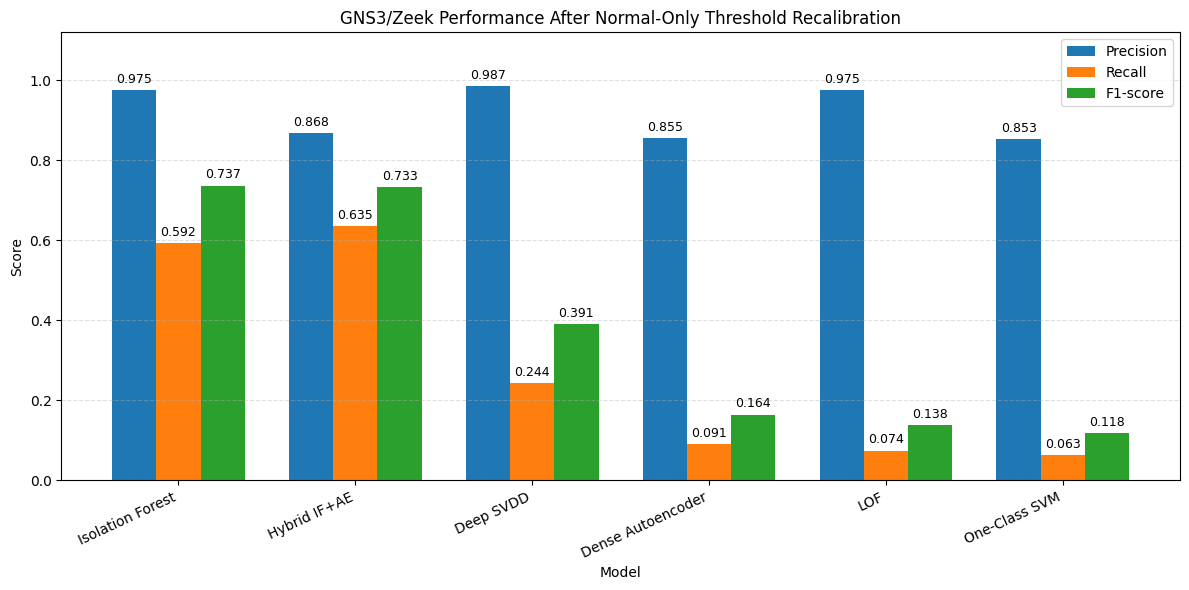

/content/drive/MyDrive/intentmap-nids/intentmap-nids/results/gns3_zeek_v5_recalibrated/GNS3_Zeek_Recalibrated_Model_Performance.png


In [ ]:
# RECALIBRATED MODEL PERFORMANCE BAR CHART
# Adds Precision, Recall and F1 values above every bar

BAR_CHART_FILE = (
    RESULT_DIR /
    "GNS3_Zeek_Recalibrated_Model_Performance.png"
)

plot_df = comparison_1pct.copy()

x = np.arange(len(plot_df))
width = 0.25

fig, ax = plt.subplots(
    figsize=(12, 6)
)

# Precision bars
bars_precision = ax.bar(
    x - width,
    plot_df["Precision"],
    width,
    label="Precision"
)

# Recall bars
bars_recall = ax.bar(
    x,
    plot_df["Recall"],
    width,
    label="Recall"
)

# F1 bars
bars_f1 = ax.bar(
    x + width,
    plot_df["F1"],
    width,
    label="F1-score"
)

# ------------------------------------------------------------
# ADD RESULT VALUES ABOVE EACH BAR
# ------------------------------------------------------------

ax.bar_label(
    bars_precision,
    labels=[f"{v:.3f}" for v in plot_df["Precision"]],
    padding=3,
    fontsize=9
)

ax.bar_label(
    bars_recall,
    labels=[f"{v:.3f}" for v in plot_df["Recall"]],
    padding=3,
    fontsize=9
)

ax.bar_label(
    bars_f1,
    labels=[f"{v:.3f}" for v in plot_df["F1"]],
    padding=3,
    fontsize=9
)

# ------------------------------------------------------------
# FORMAT
# ------------------------------------------------------------

ax.set_xticks(x)

ax.set_xticklabels(
    plot_df["Model"],
    rotation=25,
    ha="right"
)

# Slightly higher limit so labels have enough room
ax.set_ylim(
    0,
    1.12
)

ax.set_ylabel(
    "Score"
)

ax.set_xlabel(
    "Model"
)

ax.set_title(
    "GNS3/Zeek Performance After "
    "Normal-Only Threshold Recalibration"
)

ax.legend()

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    BAR_CHART_FILE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(BAR_CHART_FILE)

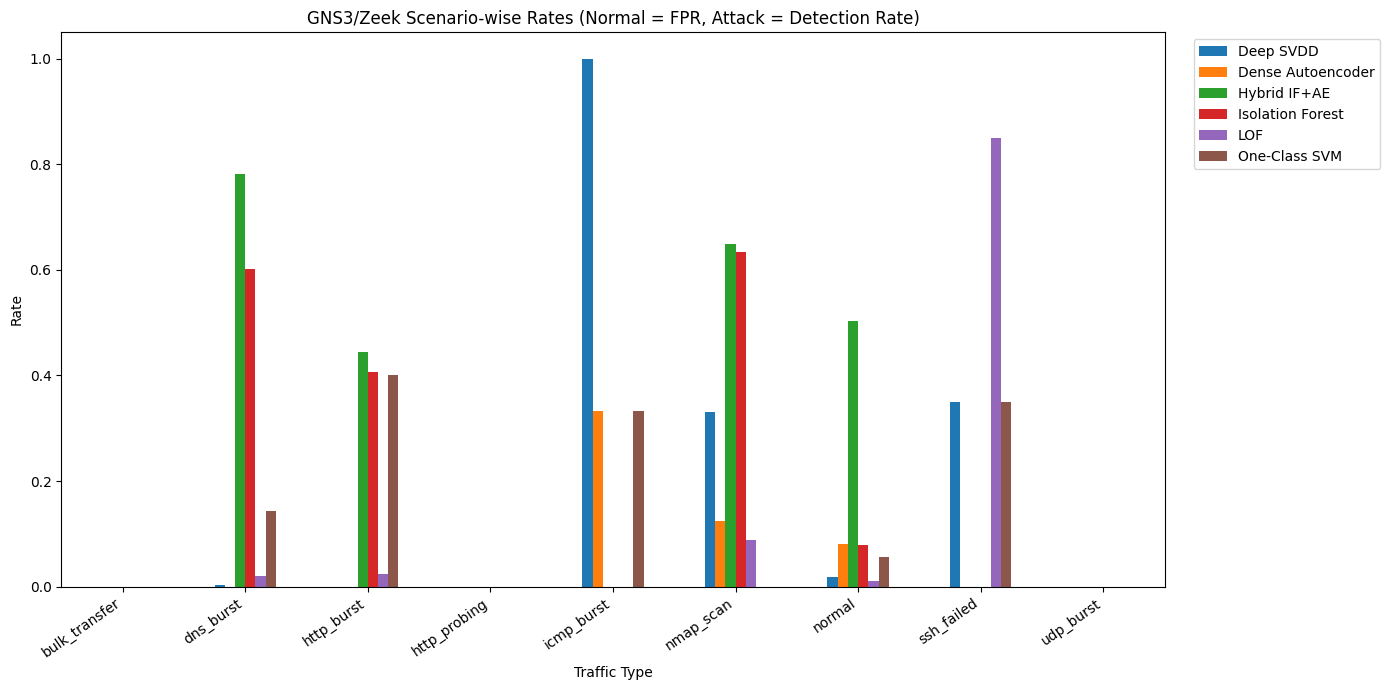

/content/drive/MyDrive/intentmap-nids/intentmap-nids/results/gns3_zeek_v5_recalibrated/GNS3_Zeek_Recalibrated_Per_Scenario.png


In [ ]:
# PER-SCENARIO RATE CHART

SCENARIO_CHART_FILE = (
    RESULT_DIR /
    "GNS3_Zeek_Recalibrated_Per_Scenario.png"
)

scenario_pivot = (
    scenario_results
    .pivot(
        index="Traffic Type",
        columns="Model",
        values="Rate"
    )
)

scenario_pivot.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.ylabel(
    "Rate"
)

plt.ylim(
    0,
    1.05
)

plt.title(
    "GNS3/Zeek Scenario-wise Rates "
    "(Normal = FPR, Attack = Detection Rate)"
)

plt.xticks(
    rotation=35,
    ha="right"
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    SCENARIO_CHART_FILE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    SCENARIO_CHART_FILE
)

In [ ]:
# CREATE ZIP AND DOWNLOAD

from google.colab import files

ZIP_FILE = (
    RESULT_DIR /
    "GNS3_Zeek_Recalibrated_Results.zip"
)

with zipfile.ZipFile(
    ZIP_FILE,
    "w",
    zipfile.ZIP_DEFLATED
) as zip_file:

    for file in [
        EXCEL_FILE,
        RECORD_FILE,
        BAR_CHART_FILE,
        SCENARIO_CHART_FILE,
        THRESHOLD_FILE
    ]:

        zip_file.write(
            file,
            arcname=file.name
        )


print(
    "ZIP created:"
)

print(
    ZIP_FILE
)

files.download(
    str(ZIP_FILE)
)

ZIP created:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/results/gns3_zeek_v5_recalibrated/GNS3_Zeek_Recalibrated_Results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>